# Chinese Punctuation Restoration - Comprehensive Evaluation

This notebook evaluates the trained model and generates visualizations including:
- Training progress plots (loss, accuracy, F1-scores)
- Confusion matrices
- Per-class performance metrics
- Comparison charts

UPDATE: v1 support Chinese punctuation marks display in figures.

## 1. Setup and Imports


In [1]:
import os
os.environ['TRANSFORMERS_NO_TF'] = '1'

import pandas as pd
import numpy as np
from transformers import BertTokenizer
import torch
from torch import nn
%matplotlib inline
import json
from tqdm import tqdm
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from model import BertChineseEmbSlimCNNlstmBert
from data_utils import load_file, preprocess_data, create_data_loader

# Configure matplotlib to support Chinese characters
def setup_chinese_font():
    """Setup matplotlib to use a font that supports Chinese characters"""
    # Try common Chinese fonts in order of preference
    chinese_fonts = [
        # macOS
        'PingFang SC', 'STHeiti', 'Heiti SC', 'Arial Unicode MS',
        # Linux
        'WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei',
        # Windows
        'Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi'
    ]
    
    # Get all available fonts
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    # Find the first available Chinese font
    font_found = None
    font_prop = None
    for font_name in chinese_fonts:
        if font_name in available_fonts:
            font_found = font_name
            # Get the font properties object
            for f in fm.fontManager.ttflist:
                if f.name == font_name:
                    try:
                        font_prop = fm.FontProperties(fname=f.fname, size=10)
                    except:
                        # Fallback: create from name
                        font_prop = fm.FontProperties(family=font_name, size=10)
                    break
            if font_prop:
                break
    
    if font_found:
        # Set font for matplotlib - put Chinese font first in the list
        plt.rcParams['font.sans-serif'] = [font_found] + [f for f in plt.rcParams['font.sans-serif'] if f != font_found]
        plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display
        
        # Also configure seaborn to use the same font
        sns.set(font=font_found)
        
        print(f"✓ Using Chinese font: {font_found}")
        print(f"✓ Font configured for matplotlib and seaborn")
        
        # Test if Chinese characters can be displayed
        test_fig, test_ax = plt.subplots(figsize=(1, 1))
        test_ax.text(0.5, 0.5, '，。？', fontsize=20, ha='center', va='center')
        test_ax.set_xlim(0, 1)
        test_ax.set_ylim(0, 1)
        test_ax.axis('off')
        plt.close(test_fig)  # Close test figure immediately
        print(f"✓ Chinese characters test passed: ，。？")
        
        return font_found, font_prop
    else:
        print("⚠ Warning: No Chinese font found. Chinese characters may not display correctly.")
        print("Available fonts containing 'Chinese' or 'CJK':")
        chinese_related = [f for f in available_fonts if any(keyword in f for keyword in ['Chinese', 'CJK', 'Hei', 'Song', 'Kai'])]
        if chinese_related:
            print(f"  Try: {chinese_related[:5]}")
        return None, None

# Set style for better plots FIRST
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Setup Chinese font support AFTER style (so it overrides style defaults)
chinese_font_name, chinese_font_prop = setup_chinese_font()

# Configuration
CUDA = torch.cuda.is_available()
device = torch.device("cuda" if CUDA else "cpu")
print(f"Using device: {device}")


✓ Using Chinese font: Arial Unicode MS
✓ Font configured for matplotlib and seaborn
✓ Chinese characters test passed: ，。？
Using device: cpu


## 2. Model Configuration


In [2]:
# Update these paths to match your model
model_path = 'outputs/model_v3_20251112_014948/model'
hyperparameters_path = 'outputs/model_v3_20251112_014948/hyperparameters.json'
progress_csv_path = 'outputs/model_v3_20251112_014948/progress.csv'
test_data_path = 'data/test'

# Optional: limit test data for faster evaluation
MAX_TEST_LINES = None  # Set to a number (e.g., 10000) to limit, or None for all


## 3. Load Model and Configuration


In [3]:
# Load hyperparameters
with open(hyperparameters_path, 'r', encoding='utf-8') as f:
    hyperparams = json.load(f)

seq_len = hyperparams['seq_len']
dropout = hyperparams['dropout']
punctuation_enc = hyperparams['punctuation_enc']
output_size = len(punctuation_enc)

print(f"Sequence length: {seq_len}")
print(f"Dropout: {dropout}")
print(f"Output size: {output_size}")
print(f"Punctuation encoding: {punctuation_enc}")

hyperparams


Sequence length: 200
Dropout: 0.1
Output size: 4
Punctuation encoding: {'O': 0, '，': 1, '。': 2, '？': 3}


{'seq_len': 200,
 'dropout': 0.1,
 'epochs': 15,
 'batch_size': 40,
 'learning_rate': 1e-05,
 'iterations': 3,
 'max_train_lines': 150000,
 'max_valid_lines': 50000,
 'punctuation_enc': {'O': 0, '，': 1, '。': 2, '？': 3},
 'class_weights': {'O': 1.0,
  '，': 24.930660247802734,
  '。': 23.184886932373047,
  '？': 313.0748291015625}}

In [4]:
# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('hfl/chinese-roberta-wwm-ext', do_lower_case=True)
print("✓ Tokenizer loaded")


✓ Tokenizer loaded


In [5]:
# Initialize and load model
model = BertChineseEmbSlimCNNlstmBert(seq_len, output_size, dropout, None)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()
print("✓ Model loaded")


✓ Model loaded


## 4. Training Progress Visualization


In [6]:
# Load training progress
if os.path.exists(progress_csv_path):
    progress = pd.read_csv(progress_csv_path, delimiter=';')
    print(f"Loaded {len(progress)} rows of training progress")
    display(progress.head())
else:
    print(f"Progress file not found: {progress_csv_path}")
    progress = None


Loaded 45 rows of training progress


,time,epoch,iteration,training_loss,val_loss,accuracy,f1_O,f1_，,f1_。,f1_？
0,2025-11-12 01:52:56,1,1,1.3766,1.2938,0.4390,0.6070,0.0758,0.1188,0.0427
1,2025-11-12 01:56:02,1,2,1.2905,1.1826,0.5272,0.6919,0.1131,0.1758,0.0602
2,2025-11-12 01:58:08,1,3,1.1931,1.0944,0.7286,0.8541,0.1506,0.2664,0.0643
3,2025-11-12 02:01:16,2,1,1.0877,0.9659,0.7523,0.8695,0.2103,0.3110,0.0972
4,2025-11-12 02:04:23,2,2,0.9599,0.8601,0.8431,0.9265,0.2277,0.4247,0.1442


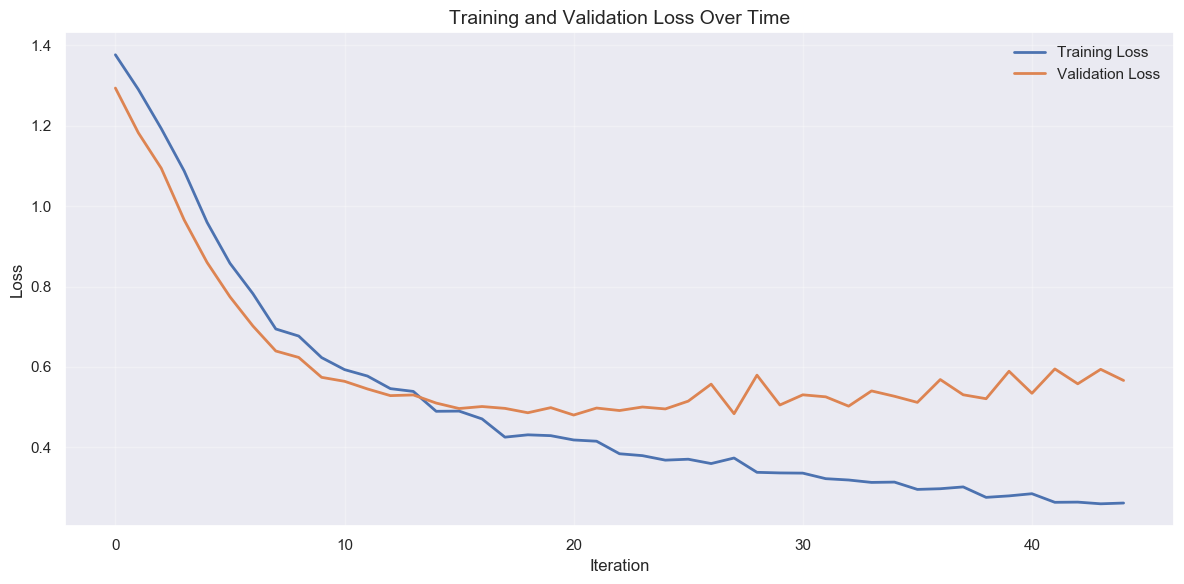

In [7]:
# Plot training and validation loss
if progress is not None and 'training_loss' in progress.columns and 'val_loss' in progress.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(progress['training_loss'], label='Training Loss', linewidth=2)
    ax.plot(progress['val_loss'], label='Validation Loss', linewidth=2)
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training and Validation Loss Over Time', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


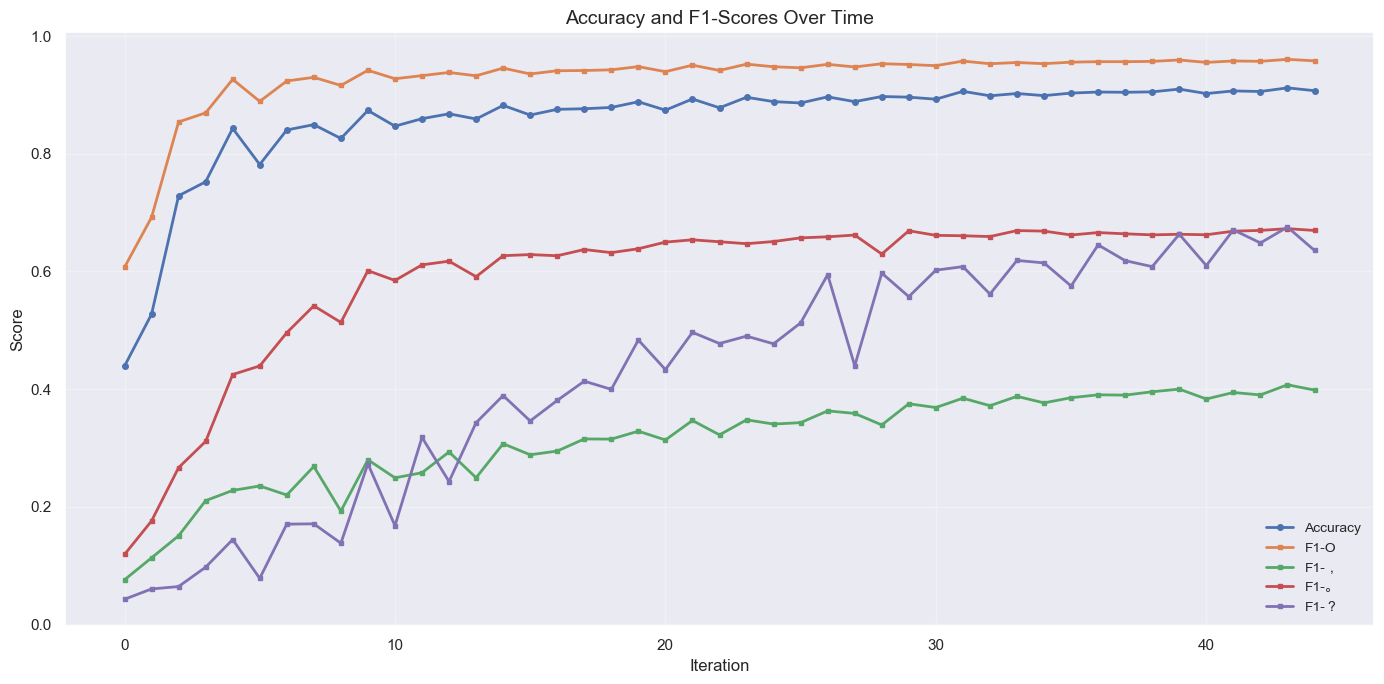

In [8]:
# Plot accuracy and F1-scores over time
if progress is not None:
    fig, ax = plt.subplots(figsize=(14, 7))
    
    if 'accuracy' in progress.columns:
        ax.plot(progress['accuracy'], label='Accuracy', linewidth=2, marker='o', markersize=4)
    
    # Plot F1-scores for each punctuation class
    f1_cols = [col for col in progress.columns if col.startswith('f1_')]
    for col in f1_cols:
        label = col.replace('f1_', '')
        ax.plot(progress[col], label=f'F1-{label}', linewidth=2, marker='s', markersize=3)
    
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Accuracy and F1-Scores Over Time', fontsize=14, fontweight='bold')
    # Set font for legend to ensure Chinese characters display correctly
    if chinese_font_name:
        font_prop_legend = fm.FontProperties(family=chinese_font_name, size=10)
        ax.legend(fontsize=10, loc='best', prop=font_prop_legend)
    else:
        ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5. Load and Preprocess Test Data


In [9]:
# Load test data
if MAX_TEST_LINES:
    from data_utils import load_file_limited
    data_test = load_file_limited(test_data_path, max_lines=MAX_TEST_LINES)
    print(f"Test samples: {len(data_test)} (limited to {MAX_TEST_LINES:,} lines)")
else:
    data_test = load_file(test_data_path)
    print(f"Test samples: {len(data_test)}")


Test samples: 150859


In [10]:
# Preprocess data
X_test, y_test = preprocess_data(data_test, tokenizer, punctuation_enc, seq_len)
print(f"Test sequences: {X_test.shape[0]:,}")
print(f"Sequence length: {X_test.shape[1]}")


Test sequences: 754
Sequence length: 200


In [11]:
# Create data loader
batch_size = 32
data_loader_test = create_data_loader(X_test, y_test, shuffle=False, batch_size=batch_size)
print(f"Number of batches: {len(data_loader_test)}")


Number of batches: 24


## 6. Model Evaluation


In [12]:
# Get predictions
def get_predictions(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            output = model(inputs)
            labels_flat = labels.view(-1)
            
            preds = output.argmax(dim=1).cpu().numpy()
            labels_np = labels_flat.cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels_np)
    
    return all_preds, all_labels

y_pred_test, y_true_test = get_predictions(model, data_loader_test, device)
print(f"Total predictions: {len(y_pred_test):,}")


Evaluating: 100%|██████████| 24/24 [00:59<00:00,  2.49s/it]

Total predictions: 150,800


In [13]:
# Calculate metrics
label_keys = list(punctuation_enc.keys())
label_vals = list(punctuation_enc.values())

accuracy = metrics.accuracy_score(y_true_test, y_pred_test)
precision = metrics.precision_score(y_true_test, y_pred_test, average=None, labels=label_vals, zero_division=0)
recall = metrics.recall_score(y_true_test, y_pred_test, average=None, labels=label_vals, zero_division=0)
f1_scores = metrics.f1_score(y_true_test, y_pred_test, average=None, labels=label_vals, zero_division=0)

# Macro averages (excluding 'O' class)
non_o_indices = [i for i, key in enumerate(label_keys) if key != 'O']
if non_o_indices:
    macro_precision = np.mean([precision[i] for i in non_o_indices])
    macro_recall = np.mean([recall[i] for i in non_o_indices])
    macro_f1 = np.mean([f1_scores[i] for i in non_o_indices])
else:
    macro_precision = macro_recall = macro_f1 = 0.0

# Create results DataFrame
results_df = pd.DataFrame({
    'Punctuation': label_keys,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1_scores
})

print("=" * 60)
print("Evaluation Results")
print("=" * 60)
print(f"\nOverall Accuracy: {accuracy:.4f}")
print(f"\nMacro-Averaged Metrics (excluding 'O'):")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall:    {macro_recall:.4f}")
print(f"  F1-Score:  {macro_f1:.4f}")
print("\nPer-Class Metrics:")
print("-" * 60)
display(results_df)
print("-" * 60)


Evaluation Results

Overall Accuracy: 0.8907

Macro-Averaged Metrics (excluding 'O'):
  Precision: 0.3655
  Recall:    0.7730
  F1-Score:  0.4816

Per-Class Metrics:
------------------------------------------------------------


,Punctuation,Precision,Recall,F1-Score
0,O,0.996215,0.902689,0.947149
1,，,0.225721,0.667883,0.337409
2,。,0.573076,0.793070,0.665360
3,？,0.297571,0.857977,0.441884


------------------------------------------------------------


## 7. Confusion Matrix


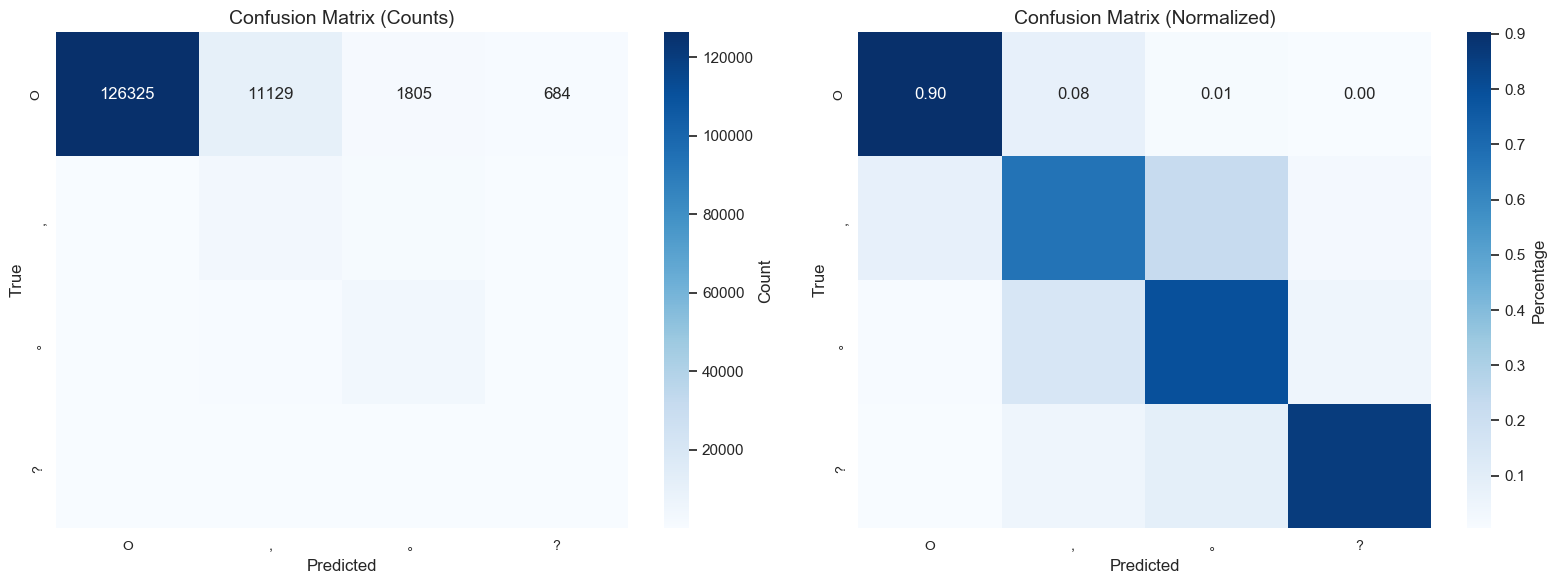

In [14]:
# Generate confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test, labels=label_vals)

# Normalize confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_keys, 
            yticklabels=label_keys, ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
# Explicitly set font for tick labels to ensure Chinese characters display
if chinese_font_name:
    font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=10)
    ax1.set_xticklabels(label_keys, fontproperties=font_prop_with_size)
    ax1.set_yticklabels(label_keys, fontproperties=font_prop_with_size)

# Normalized percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=label_keys, yticklabels=label_keys, ax=ax2,
            cbar_kws={'label': 'Percentage'})
ax2.set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('True', fontsize=12)
# Explicitly set font for tick labels to ensure Chinese characters display
if chinese_font_name:
    font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=10)
    ax2.set_xticklabels(label_keys, fontproperties=font_prop_with_size)
    ax2.set_yticklabels(label_keys, fontproperties=font_prop_with_size)

plt.tight_layout()
plt.show()


## 8. Performance Metrics Visualization


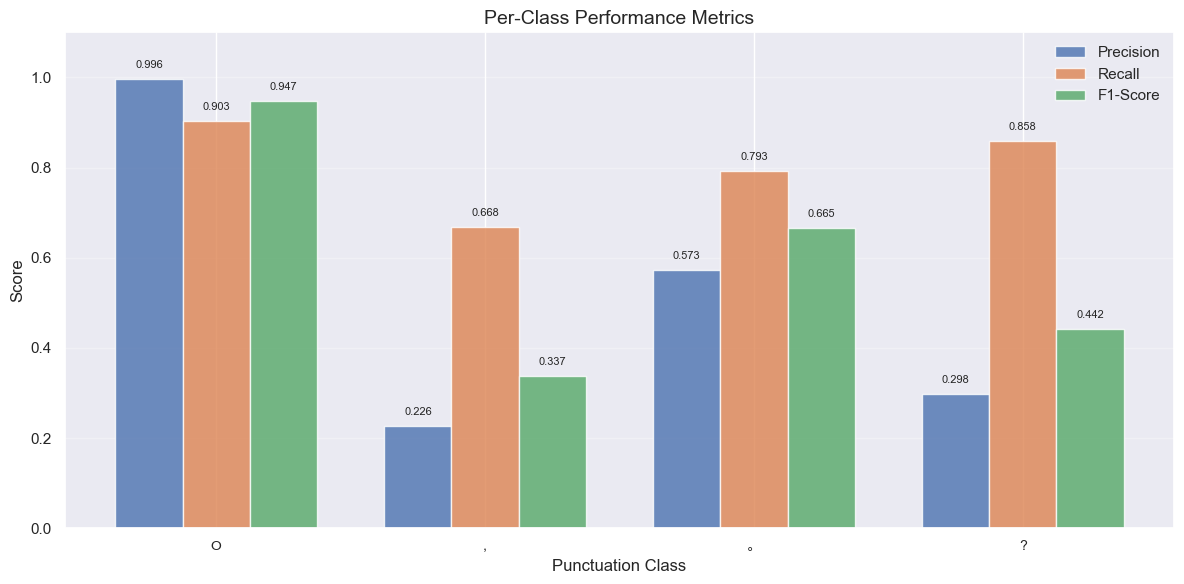

In [15]:
# Bar chart comparing Precision, Recall, and F1-Score
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x, results_df['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + width, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Punctuation Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
# Explicitly set font for x-axis labels to ensure Chinese characters display
if chinese_font_prop:
    # Create font properties with the desired size
    font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=10)
    ax.set_xticklabels(results_df['Punctuation'], fontproperties=font_prop_with_size)
else:
    ax.set_xticklabels(results_df['Punctuation'], fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

# Add value labels on bars
for i, (prec, rec, f1) in enumerate(zip(results_df['Precision'], 
                                         results_df['Recall'], 
                                         results_df['F1-Score'])):
    ax.text(i - width, prec + 0.02, f'{prec:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i, rec + 0.02, f'{rec:.3f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + width, f1 + 0.02, f'{f1:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


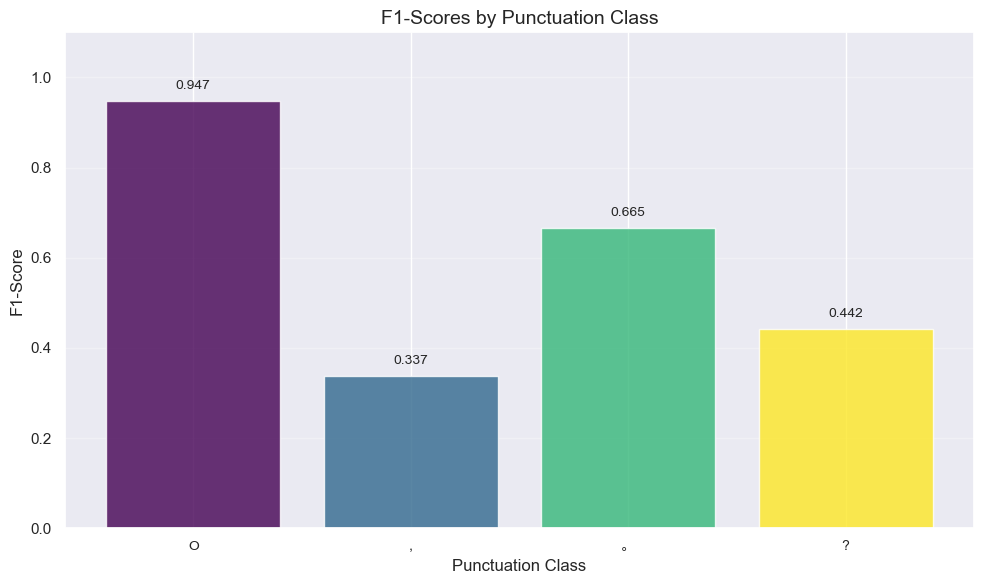

In [16]:
# F1-Scores only (bar chart)
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax.bar(range(len(results_df)), results_df['F1-Score'], color=colors, alpha=0.8)

ax.set_xlabel('Punctuation Class', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Scores by Punctuation Class', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(results_df)))
# Explicitly set font for x-axis labels to ensure Chinese characters display
if chinese_font_prop:
    # Create font properties with the desired size
    font_prop_with_size = fm.FontProperties(family=chinese_font_name, size=10)
    ax.set_xticklabels(results_df['Punctuation'], fontproperties=font_prop_with_size)
else:
    ax.set_xticklabels(results_df['Punctuation'])
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, f1 in zip(bars, results_df['F1-Score']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{f1:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 9. Detailed Classification Report


In [17]:
# Print detailed classification report
print("Detailed Classification Report:")
print("=" * 60)
print(classification_report(y_true_test, y_pred_test, 
                          target_names=label_keys, 
                          labels=label_vals,
                          zero_division=0))


Detailed Classification Report:
              precision    recall  f1-score   support

           O       1.00      0.90      0.95    139943
           ，       0.23      0.67      0.34      5206
           。       0.57      0.79      0.67      5137
           ？       0.30      0.86      0.44       514

    accuracy                           0.89    150800
   macro avg       0.52      0.81      0.60    150800
weighted avg       0.95      0.89      0.91    150800


## 10. Save Results (Optional)


In [18]:
# Save results to CSV
output_dir = 'evaluation_results'
os.makedirs(output_dir, exist_ok=True)

results_df.to_csv(os.path.join(output_dir, 'evaluation_results.csv'), index=False)
print(f"✓ Results saved to {output_dir}/evaluation_results.csv")

# Save summary
summary = {
    'overall_accuracy': float(accuracy),
    'macro_precision': float(macro_precision),
    'macro_recall': float(macro_recall),
    'macro_f1': float(macro_f1),
}
with open(os.path.join(output_dir, 'summary.json'), 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"✓ Summary saved to {output_dir}/summary.json")


✓ Results saved to evaluation_results/evaluation_results.csv
✓ Summary saved to evaluation_results/summary.json
